# 07. 応用 — 物理・金融(Black-Scholes)・画像・拡散モデル

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture |
| Applied | 2. 物理 〜 5. 拡散モデル |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

PDE は分野を越えた共通言語です。**同じ熱方程式** が、物理の熱伝導・金融の Black-Scholes・
画像の平滑化・生成 AI の拡散モデルに現れます。本章でその姿を確かめます。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 2. 物理 — 2 次元の熱伝導

これまでの 1 次元を 2 次元に拡張します。中央を熱したプレートの温度が、時間とともに
全体へ拡散していく様子を陽的 FDM(2 次元)で解きます。

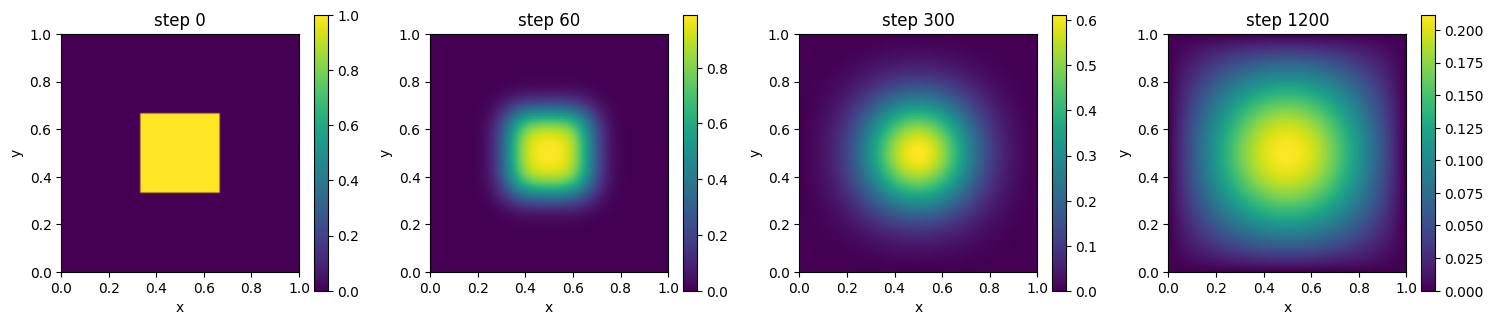

In [3]:
import numpy as np

# 2-D heat diffusion of a hot square on a cold plate (explicit, periodic-free Dirichlet 0).
n = 81
g = grids.Grid2D(0.0, 1.0, 0.0, 1.0, n, n)
dx = g.dx
alpha = 1.0
dt = 0.2 * dx**2 / alpha       # 2-D stability needs r <= 1/4; use 0.2 to be safe
u = np.zeros((n, n))
u[n // 3:2 * n // 3, n // 3:2 * n // 3] = 1.0   # hot square
snaps = {0: u.copy()}
for k in range(1, 1201):
    lap = (np.roll(u, 1, 0) + np.roll(u, -1, 0) + np.roll(u, 1, 1) + np.roll(u, -1, 1) - 4 * u)
    u = u + alpha * dt / dx**2 * lap
    u[0, :] = u[-1, :] = u[:, 0] = u[:, -1] = 0.0
    if k in (60, 300, 1200):
        snaps[k] = u.copy()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (k, snap) in zip(axes, snaps.items()):
    plotting.heatmap_2d(snap, grid=g, ax=ax, title=f"step {k}")
fig.tight_layout()
plt.show()

**アニメーション**(Play で再生):中央の熱い正方形が、時間とともに板全体へ拡散していく様子。

In [4]:
from matplotlib import animation
from IPython.display import HTML

# 2-D heat diffusion as a movie (matplotlib imshow -> to_jshtml; works offline in the book).
na = 81
ga = grids.Grid2D(0.0, 1.0, 0.0, 1.0, na, na)
dxa = ga.dx
ua = np.zeros((na, na))
ua[na // 3:2 * na // 3, na // 3:2 * na // 3] = 1.0
frames2d = [ua.copy()]
for k in range(1, 601):
    lapa = np.roll(ua, 1, 0) + np.roll(ua, -1, 0) + np.roll(ua, 1, 1) + np.roll(ua, -1, 1) - 4 * ua
    ua = ua + 0.2 * lapa
    ua[0, :] = ua[-1, :] = ua[:, 0] = ua[:, -1] = 0.0
    if k % 30 == 0:
        frames2d.append(ua.copy())
figa, axa = plt.subplots(figsize=(4.5, 4))
ima = axa.imshow(frames2d[0], origin="lower", cmap="inferno", vmin=0, vmax=1)
axa.set_title("2-D heat diffusion")
axa.set_xticks([])
axa.set_yticks([])
anim2d = animation.FuncAnimation(figa, lambda i: (ima.set_data(frames2d[i]), (ima,))[1],
                                 frames=len(frames2d), interval=150, blit=True)
plt.close(figa)
HTML(anim2d.to_jshtml())

## 3. 金融 — Black-Scholes 方程式 (Applied)

オプション価格 $V(S, t)$ は **Black-Scholes 方程式**

$$
\frac{\partial V}{\partial t} + \tfrac12\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0
$$

に従います。これは(変数変換すると)**熱方程式そのもの**。ヨーロピアン・コールには閉じた解(Black-Scholes 公式)があり、
ここでは解析解で価格曲面を描き、さらに **その曲面が PDE を満たす**(残差 ≈ 0)ことを数値微分で検証します。

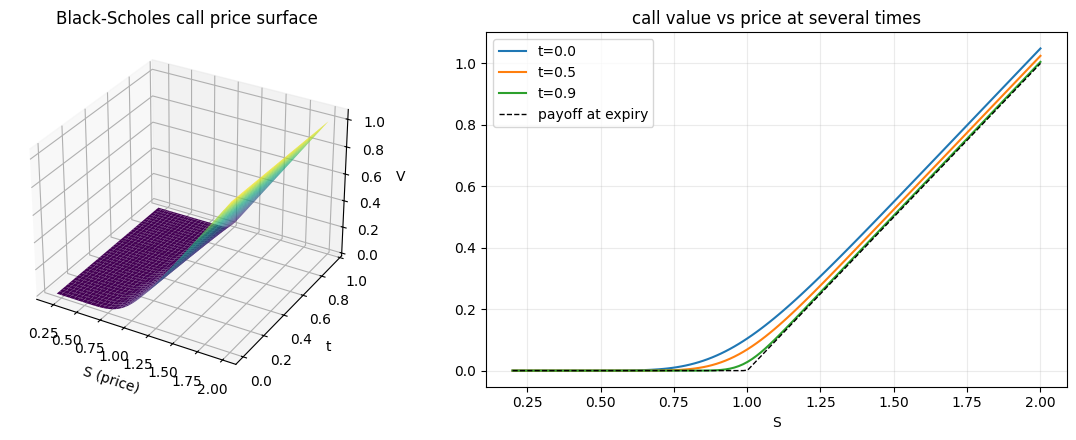

In [5]:
import numpy as np
from scipy.stats import norm

# Black-Scholes European call price surface (closed form).
def bs_call(S, t, K=1.0, r=0.05, sigma=0.2, T=1.0):
    tau = np.maximum(T - t, 1e-12)             # time to maturity
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

S = np.linspace(0.2, 2.0, 120)
tt = np.linspace(0.0, 0.95, 80)
SS, TT = np.meshgrid(S, tt)
V = bs_call(SS, TT)

fig = plt.figure(figsize=(12, 4.5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(SS, TT, V, cmap="viridis")
ax1.set_xlabel("S (price)")
ax1.set_ylabel("t")
ax1.set_zlabel("V")
ax1.set_title("Black-Scholes call price surface")
ax2 = fig.add_subplot(1, 2, 2)
for t0 in (0.0, 0.5, 0.9):
    ax2.plot(S, bs_call(S, t0), label=f"t={t0}")
ax2.plot(S, np.maximum(S - 1.0, 0), "k--", lw=1, label="payoff at expiry")
ax2.legend()
ax2.grid(alpha=0.25)
ax2.set_xlabel("S")
ax2.set_title("call value vs price at several times")
fig.tight_layout()
plt.show()

**インタラクティブ版**(ドラッグで回転・ズーム、静的 HTML でも動く):

In [6]:
import plotly.io as pio
from pde_book import interactive

pio.renderers.default = "plotly_mimetype+notebook_connected"
interactive.plotly_bs_surface().show()

In [7]:
import numpy as np
from scipy.stats import norm

# Verify the analytic surface satisfies the Black-Scholes PDE: residual ~ 0.
K, r, sigma, T = 1.0, 0.05, 0.2, 1.0
def bs_call(S, t):
    tau = max(T - t, 1e-9)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

S0, t0, h, dtau = 1.1, 0.4, 1e-4, 1e-5
V_t = (bs_call(S0, t0 + dtau) - bs_call(S0, t0 - dtau)) / (2 * dtau)
V_S = (bs_call(S0 + h, t0) - bs_call(S0 - h, t0)) / (2 * h)
V_SS = (bs_call(S0 + h, t0) - 2 * bs_call(S0, t0) + bs_call(S0 - h, t0)) / h**2
residual = V_t + 0.5 * sigma**2 * S0**2 * V_SS + r * S0 * V_S - r * bs_call(S0, t0)
print("Black-Scholes PDE residual at (S=1.1, t=0.4):", residual, " (~0 confirms it solves the PDE)")

Black-Scholes PDE residual at (S=1.1, t=0.4): -1.934803508379934e-09  (~0 confirms it solves the PDE)


## 4. 画像処理 — 拡散による平滑化

2 次元の熱方程式を画像に適用すると、**ノイズや細部がぼけて** いきます(ガウシアンぼかしと同等)。
これは画像処理の基礎で、エッジ保存拡散(異方性拡散)などへ発展します。

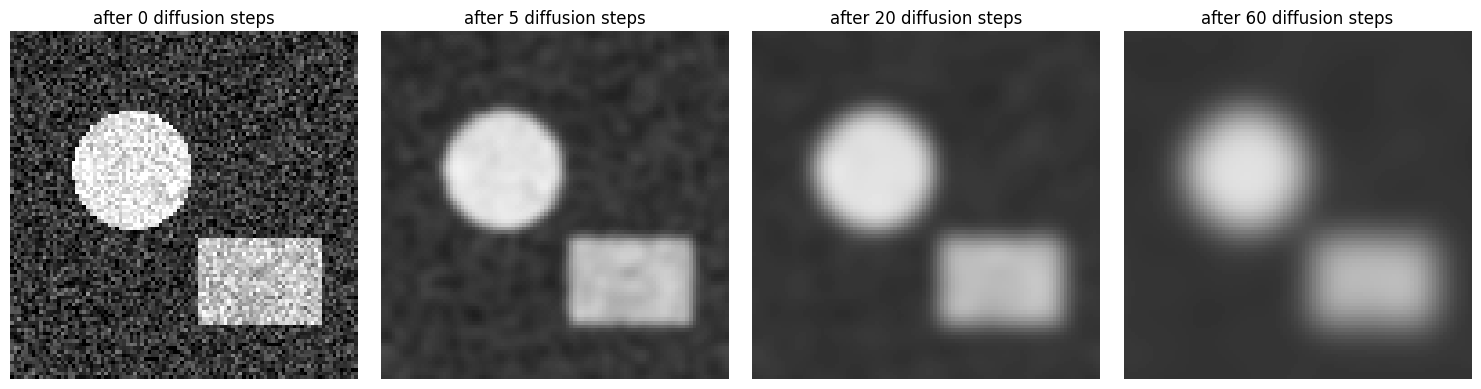

In [8]:
import numpy as np

# Image diffusion = 2-D heat equation. Noise blurs away as "time" advances.
img = datasets.make_test_image(96, seed=0)
u = img.copy()
r = 0.2  # diffusion number per step (<=1/4 for 2-D stability)
snaps = {0: u.copy()}
for k in range(1, 61):
    lap = (np.roll(u, 1, 0) + np.roll(u, -1, 0) + np.roll(u, 1, 1) + np.roll(u, -1, 1) - 4 * u)
    u = u + r * lap
    if k in (5, 20, 60):
        snaps[k] = u.copy()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (k, snap) in zip(axes, snaps.items()):
    ax.imshow(snap, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"after {k} diffusion steps")
    ax.axis("off")
fig.tight_layout()
plt.show()

## 5. 機械学習 — 拡散モデルとの概念的接続

生成 AI の **拡散モデル(diffusion models)** は、データに少しずつノイズを加えて壊す **前向き過程**
(熱方程式のように構造を拡散・破壊)と、それを逆にたどってノイズからデータを復元する **逆過程** から成ります。
ここでは 1 次元信号で「前向き = 拡散でなまる」過程だけを示します(逆過程の学習は本書の範囲外)。

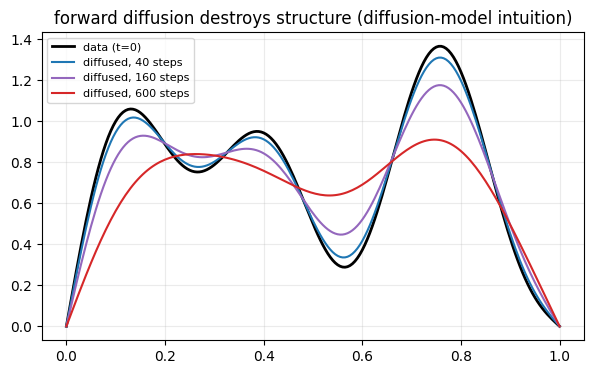

In [9]:
import numpy as np

# Forward (noising/diffusing) process intuition: structure is progressively destroyed.
g = grids.Grid1D(0.0, 1.0, 201)
x, dx = g.x, g.dx
rng = np.random.default_rng(0)
signal = datasets.sine_combo(x, (1, 3, 6), (1.0, 0.5, 0.3))
u = signal + 0.0
alpha, dt = 1.0, 0.4 * dx**2
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, signal, "k", lw=2, label="data (t=0)")
for steps, c in [(40, "#1f77b4"), (160, "#9467bd"), (600, "#d62728")]:
    U = solvers.solve_heat_explicit(signal, alpha, dx, dt, steps)
    ax.plot(x, U[-1], color=c, lw=1.5, label=f"diffused, {steps} steps")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.set_title("forward diffusion destroys structure (diffusion-model intuition)")
plt.show()

## Exercises

1. 2 次元熱伝導で安定条件が $r = \alpha\Delta t/\Delta x^2 \le 1/4$(1 次元の半分)になる理由を述べよ。
2. Black-Scholes 価格曲面の残差を別の $(S, t)$ でも評価し、満期 $t\to T$ 近くで数値誤差が増えることを観察せよ。
3. 画像拡散で、拡散ステップ数とぼけ具合(エッジの鈍り)の関係を調べよ。

## Advanced Notes

- **Black-Scholes ↔ 熱方程式**: 変数変換 $S = K e^{x},\ t = T - 2\tau/\sigma^2$ で BS 方程式は標準熱方程式に化ける。だから数値解も熱方程式の道具がそのまま使える。
- **異方性拡散 (Perona-Malik)**: 拡散係数を勾配の大きさで変え、エッジを保ちながら平坦部だけ平滑化する。
- **スコアベース生成モデル**: 拡散モデルの逆過程は確率微分方程式(SDE)で記述され、スコア関数 $\nabla\log p$ を学習する。PDE(Fokker-Planck)・SDE・最適輸送が交差する最前線。
- **有限要素法 (FEM)**: 複雑形状では差分より有限要素が標準。弱形式 + 基底関数で離散化する。